# Daily Energy Consumption

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SCRIPT_DIR = Path.cwd()
DATA_DIR = SCRIPT_DIR / "data" / "daily"

In [3]:
df = pd.read_csv("/Users/andresholee/Desktop/utility_billy/data/daily/usage_day_2026-06-08.csv")

In [4]:
files = sorted(DATA_DIR.glob("*.csv"))
if not files:
    print(f"No CSVs found in {DATA_DIR}. Drop your monthly exports there and rerun.")

frames = []
for f in files:
    try:
        df = pd.read_csv(f, encoding="utf-8-sig")
        df.columns = [c.strip() for c in df.columns]
        df["time_period"] = pd.to_datetime(df["Time period"].str.split("-").str[0].str.strip(),format="%I:%M %p").dt.time
        df["consumption_kwh"] = pd.to_numeric(df["Consumption"], errors="coerce")
        df["date"] = pd.to_datetime(f.stem.split("_")[-1]).date()
        df = df.drop(columns=["Service", "Consumption unit", "Meter serial number", "Register serial number","Counter time frame"])
        frames.append(df)
    except Exception as e:
        print(f"  ! skipping {f.name}: {e}")

combined = pd.concat(frames, ignore_index=True).sort_values(["date", "time_period"]).reset_index(drop=True)

In [5]:
combined.head(5)

,Time period,Consumption,time_period,consumption_kwh,date
0,12:00 AM-12:59 AM,1.99,00:00:00,1.99,2026-06-08
1,1:00 AM-1:59 AM,2.34,01:00:00,2.34,2026-06-08
2,2:00 AM-2:59 AM,1.95,02:00:00,1.95,2026-06-08
3,3:00 AM-3:59 AM,1.92,03:00:00,1.92,2026-06-08
4,4:00 AM-4:59 AM,2.13,04:00:00,2.13,2026-06-08


<Axes: title={'center': 'Avg kWh by hour: weekday vs weekend'}, xlabel='time_period'>

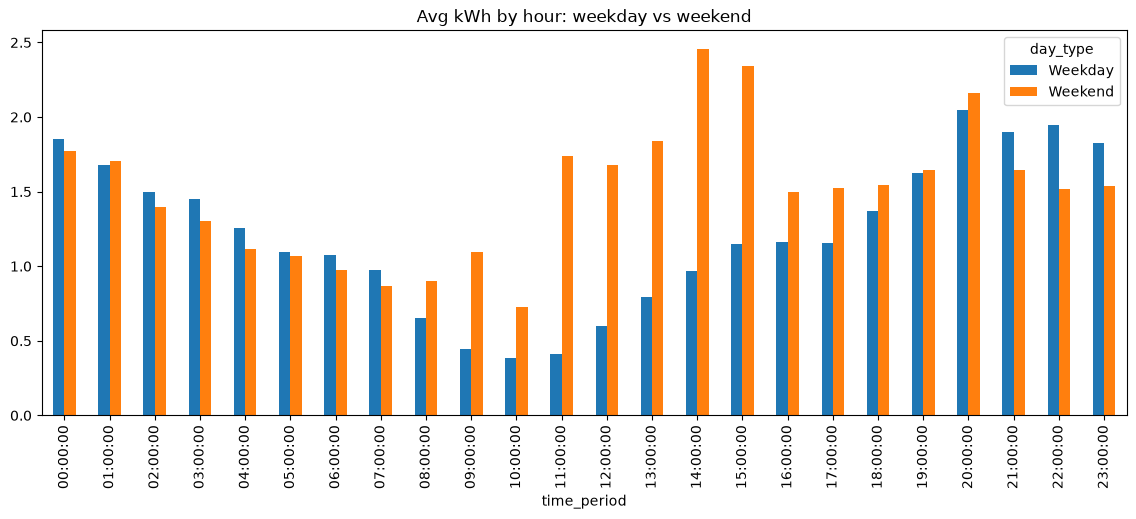

In [7]:
import numpy as np
combined["day_type"] = np.where(pd.to_datetime(combined["date"]).dt.dayofweek >= 5, "Weekend", "Weekday")
pivot = combined[combined["consumption_kwh"] > 0].pivot_table(
    index="time_period", columns="day_type", values="consumption_kwh", aggfunc="mean"
)
pivot.plot(kind="bar", figsize=(14, 5), title="Avg kWh by hour: weekday vs weekend")

<Axes: xlabel='dow', ylabel='time_period'>

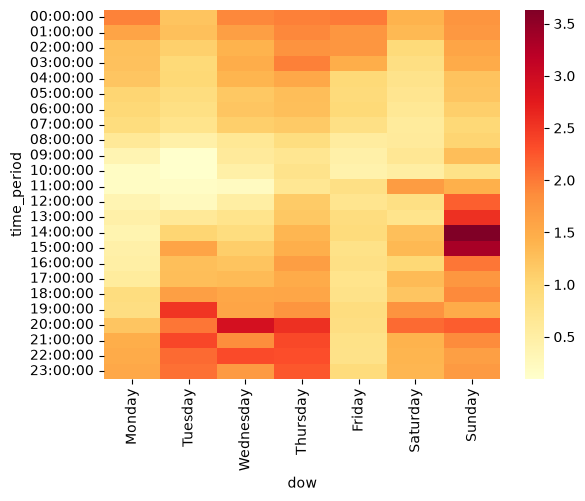

In [8]:
import seaborn as sns
combined["dow"] = pd.to_datetime(combined["date"]).dt.day_name()
heat = combined.pivot_table(index="time_period", columns="dow", values="consumption_kwh", aggfunc="mean")
heat = heat[["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]]  # order
sns.heatmap(heat, cmap="YlOrRd")